### Model Explainability

Understanding how machine learning models make predictions is crucial
for building trustworthy forecasting systems.

In this notebook we apply **SHAP (SHapley Additive Explanations)** to
interpret the restaurant demand forecasting model.

SHAP allows us to:

• measure the impact of each feature on model predictions  
• identify the most influential demand drivers  
• understand how specific features affect individual forecasts  

This analysis helps validate the model and provides insights into the
factors that drive restaurant demand.

In [1]:
"""
Import libraries for model explainability.
"""

import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
"""
Load feature-engineered dataset.
"""

df = pd.read_csv("../data/restaurant_features.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.head()

,date,day_of_week,dow,month,year,week_of_year,is_weekend,weekly_factor,seasonal_factor,trend,...,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_std_14,momentum_1_7,momentum_7_14,dow_sin,dow_cos,month_sin,month_cos
0,2016-01-31,Sunday,6,1,2016,4,1,1.25,1.101734,1.002568,...,171.285714,171.700000,24.533747,27.691789,38.0,-29.0,-0.781831,0.623490,0.500000,0.866025
1,2016-02-01,Monday,0,2,2016,5,0,1.00,1.104683,1.002653,...,171.571429,174.933333,28.641462,28.193601,72.0,4.0,0.000000,1.000000,0.866025,0.500000
2,2016-02-02,Tuesday,1,2,2016,5,0,1.00,1.107601,1.002739,...,171.642857,173.966667,29.319261,28.116809,-30.0,23.0,0.781831,0.623490,0.866025,0.500000
3,2016-02-03,Wednesday,2,2,2016,5,0,1.00,1.110487,1.002824,...,172.785714,171.900000,29.854409,27.532299,-2.0,2.0,0.974928,-0.222521,0.866025,0.500000
4,2016-02-04,Thursday,3,2,2016,5,0,1.00,1.113340,1.002910,...,173.142857,171.866667,29.631065,27.483861,5.0,13.0,0.433884,-0.900969,0.866025,0.500000


In [3]:
"""
Load trained forecasting model.
"""

model = joblib.load("../models/demand_forecasting_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [4]:
"""
Prepare feature matrix used by the model.
"""

target = "total_orders"

numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns

features = [
    col for col in numeric_features
    if col != target
]

X = df[features]

In [5]:
"""
Initialize SHAP explainer for tree-based models.
"""

explainer = shap.Explainer(model)

shap_values = explainer(X)

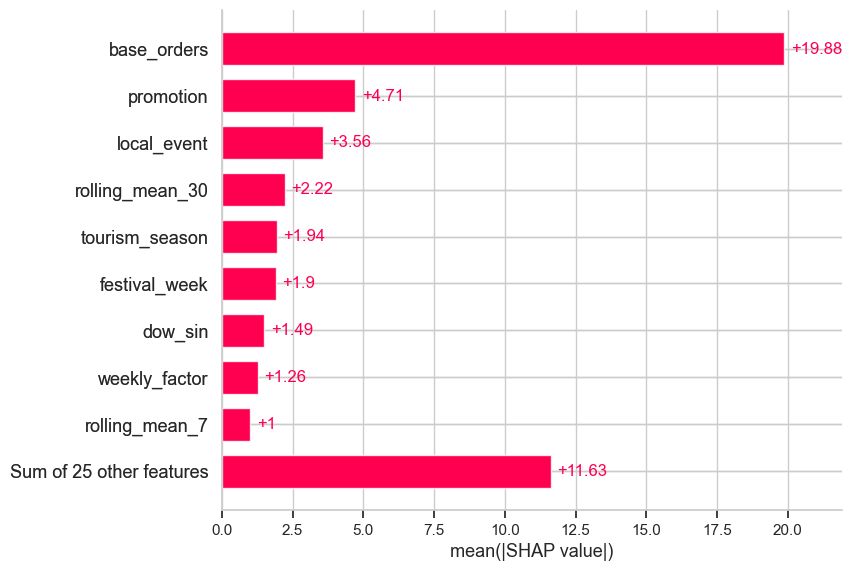

In [6]:
"""
Visualize overall feature importance using SHAP values.
"""

shap.plots.bar(shap_values)

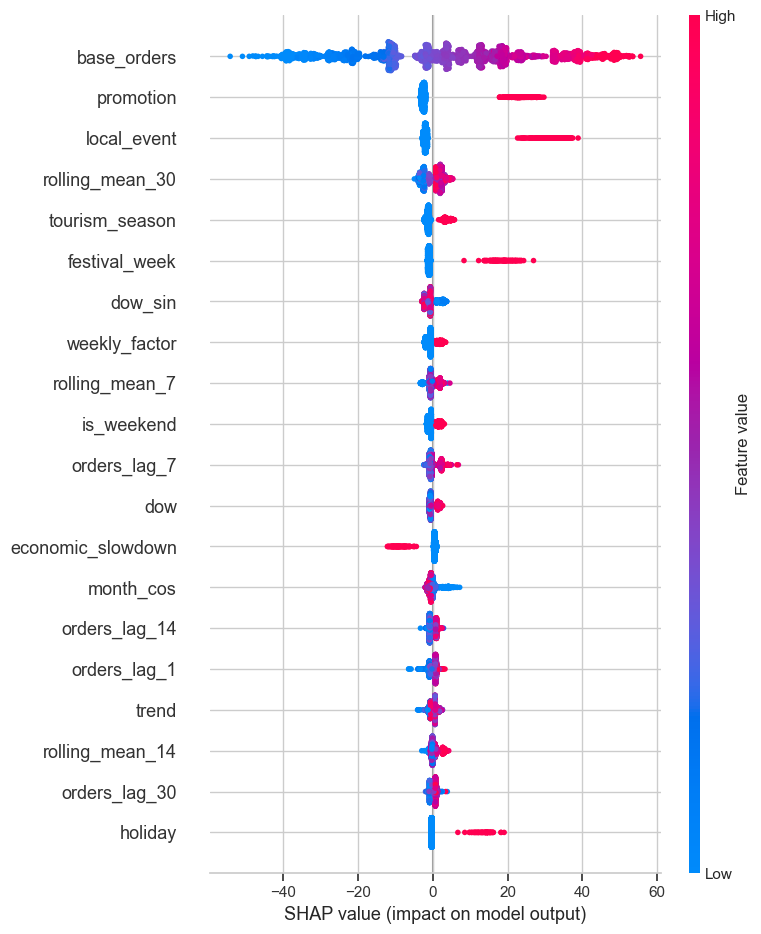

In [7]:
"""
Visualize how each feature influences predictions.
"""

shap.summary_plot(shap_values, X)

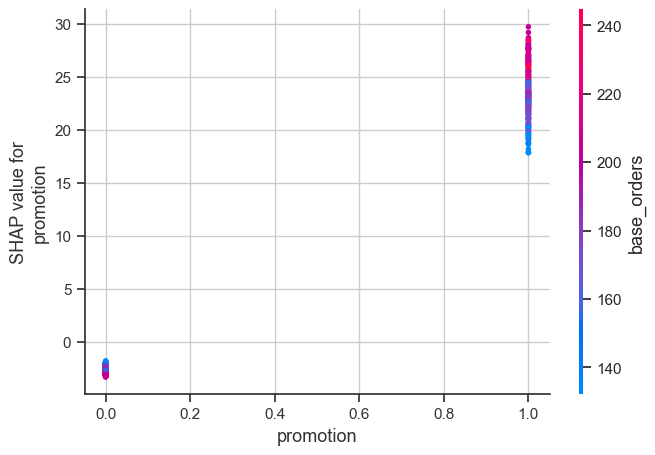

In [8]:
"""
Analyze relationship between promotion and predicted demand.
"""

shap.dependence_plot(
    "promotion",
    shap_values.values,
    X
)

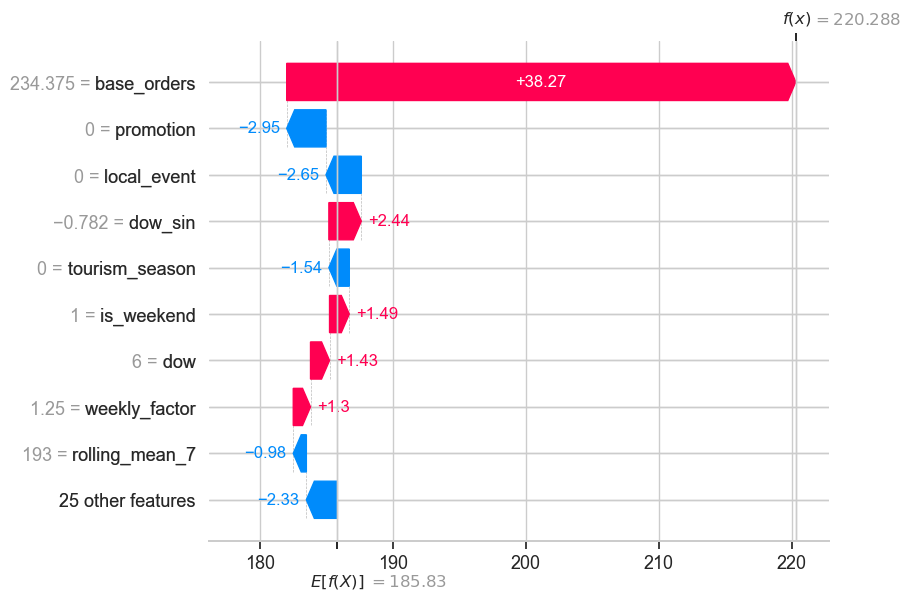

In [9]:
"""
Explain an individual prediction.
"""

index = -1

shap.plots.waterfall(shap_values[index])

#### Model Explainability Insights

The SHAP analysis provides valuable insights into the drivers of
restaurant demand predictions.

The most influential factors include:

• the base demand component  
• promotions and local events  
• recent demand trends captured by rolling averages  
• seasonal patterns such as day-of-week effects  

SHAP values also show how individual features influence predictions,
allowing us to understand both **global model behavior** and
**individual forecasts**.

These insights help validate the forecasting model and provide
business-relevant explanations for demand fluctuations.